# Ocean Observation Access & QC — NDBC Buoy

**Runnable companion to [`ocean-obs-guide.md`](../ocean-obs-guide.md).**

This notebook accesses **real moored-buoy observations** from the NOAA National
Data Buoy Center (NDBC): significant wave height, dominant wave period, sea
surface temperature, and wind. It then runs basic range QC and a few standard
sea-state diagnostics.

**Buoy:** `51201` — Waimea Bay, Hawaii (a well-exposed deep-water wave buoy).

> The NDBC realtime feed covers roughly the last 45 days, so the exact dates
> shift over time; the committed cache keeps this notebook reproducible offline.
> See [`../../NOTEBOOKS.md`](../../NOTEBOOKS.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from meteo_examples import dataio

BUOY = "51201"
b = dataio.ndbc_realtime(BUOY).set_index("time").sort_index()
# Standard met columns: WVHT (m), DPD (s), WTMP (degC), WSPD (m/s), PRES (hPa)
cols = [c for c in ["WVHT", "DPD", "APD", "MWD", "WTMP", "WSPD", "PRES"] if c in b.columns]
print(f"{len(b)} records | {b.index.min()} -> {b.index.max()}")
b[cols].describe().round(2)

1511 records | 2026-05-06 01:26:00 -> 2026-06-08 05:56:00


,WVHT,DPD,APD,MWD,WTMP,WSPD,PRES
count,1511.00,1511.00,1511.00,1511.00,1511.00,0.0,0.0
mean,1.54,10.12,6.14,192.23,25.17,NaN,NaN
std,0.29,2.58,0.90,150.69,0.29,NaN,NaN
min,1.00,5.00,4.20,1.00,22.70,NaN,NaN
25%,1.30,8.00,5.60,34.00,25.00,NaN,NaN
50%,1.50,10.00,6.00,310.00,25.10,NaN,NaN
75%,1.70,12.00,6.40,331.00,25.30,NaN,NaN
max,2.40,18.00,9.80,359.00,27.00,NaN,NaN


## 1 · Range QC

Flag physically impossible values before plotting.

In [2]:
LIMITS = {"WVHT": (0, 20), "DPD": (0, 30), "WTMP": (-2, 36), "WSPD": (0, 60), "PRES": (850, 1080)}
qc = pd.DataFrame(index=b.index)
for v, (lo, hi) in LIMITS.items():
    if v in b:
        qc[v] = ((b[v] < lo) | (b[v] > hi)).fillna(False)
print("values flagged out-of-range:")
print(qc.sum())

values flagged out-of-range:
WVHT    0
DPD     0
WTMP    0
WSPD    0
PRES    0
dtype: int64


## 2 · Time series: waves, period, SST, wind

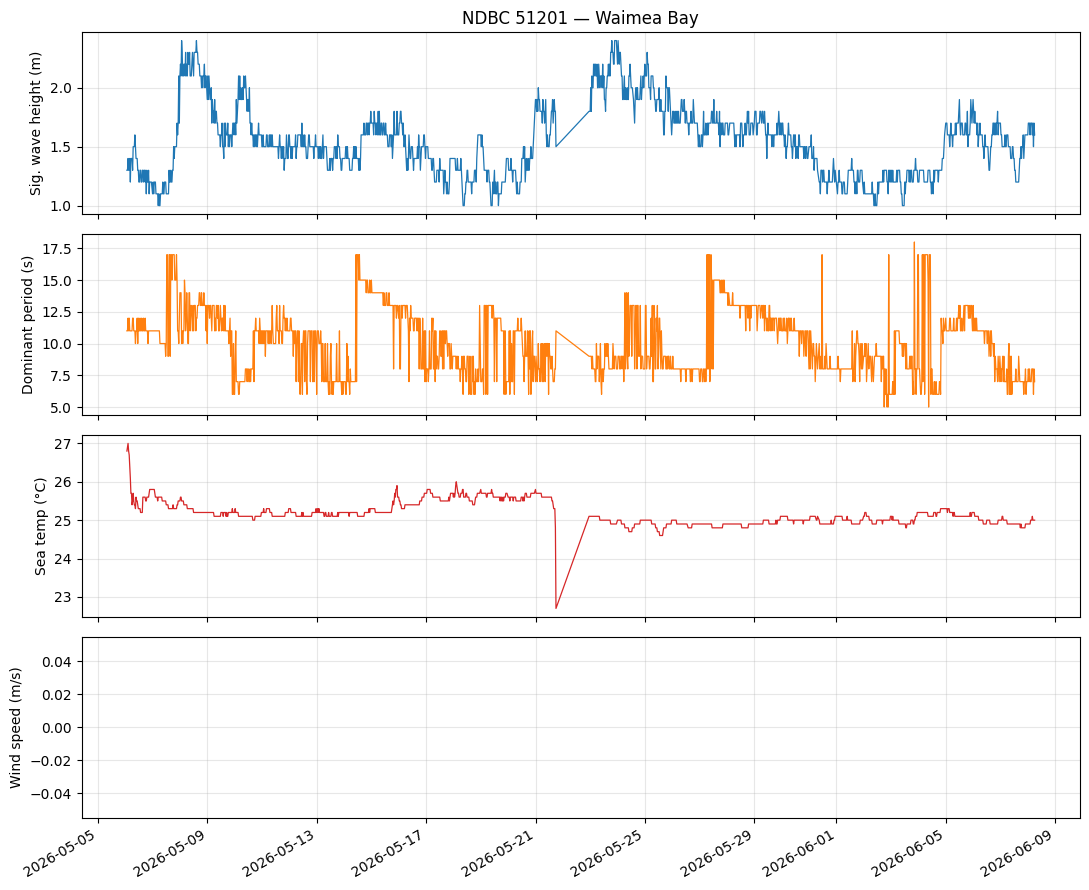

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
specs = [("WVHT", "Sig. wave height (m)", "C0"),
         ("DPD",  "Dominant period (s)",  "C1"),
         ("WTMP", "Sea temp (°C)",        "C3"),
         ("WSPD", "Wind speed (m/s)",     "C2")]
for ax, (v, lab, color) in zip(axes, specs):
    if v in b:
        ax.plot(b.index, b[v], lw=0.9, color=color)
        ax.set_ylabel(lab); ax.grid(alpha=0.3)
axes[0].set_title(f"NDBC {BUOY} — Waimea Bay")
fig.autofmt_xdate(); plt.tight_layout()

## 3 · Sea-state diagnostics

The distribution and exceedance of significant wave height summarise the wave
climate over the record — useful context for wave-model verification
([WW3](../../models/ww3-model-guide.md) / [SWAN](../../models/swan-model-guide.md)).

Hs: mean=1.54 m, 95th pct=2.10 m, max=2.40 m


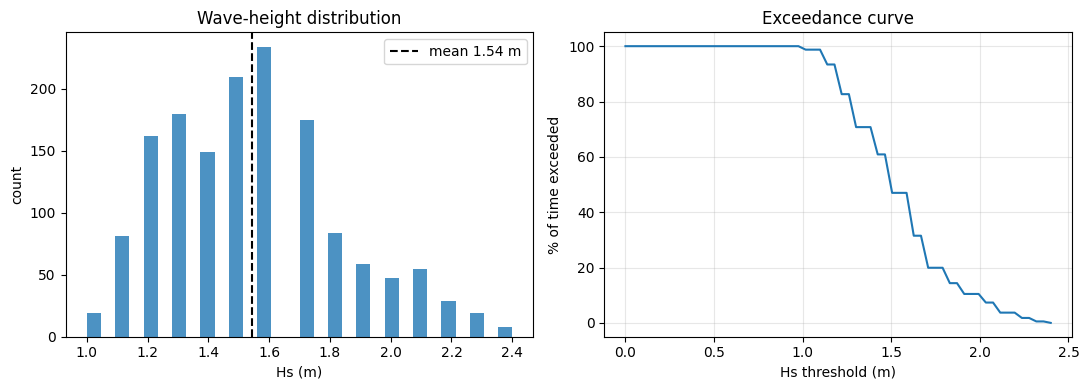

In [4]:
wvht = b["WVHT"].dropna()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.hist(wvht, bins=30, alpha=0.8, color="C0")
a1.axvline(wvht.mean(), color="k", ls="--", label=f"mean {wvht.mean():.2f} m")
a1.set(xlabel="Hs (m)", ylabel="count", title="Wave-height distribution"); a1.legend()

thr = np.linspace(0, wvht.max(), 60)
exceed = [(wvht > t).mean() * 100 for t in thr]
a2.plot(thr, exceed, color="C0")
a2.set(xlabel="Hs threshold (m)", ylabel="% of time exceeded", title="Exceedance curve")
a2.grid(alpha=0.3); plt.tight_layout()
print(f"Hs: mean={wvht.mean():.2f} m, 95th pct={np.percentile(wvht,95):.2f} m, max={wvht.max():.2f} m")

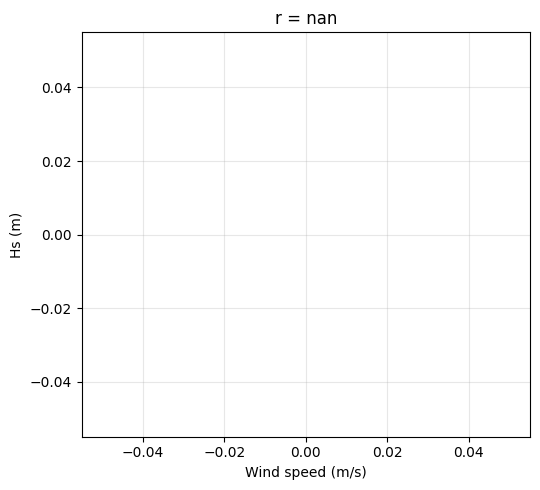

In [5]:
# Wave height vs wind speed — wind-sea vs swell signature
both = b[["WVHT", "WSPD"]].dropna()
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(both["WSPD"], both["WVHT"], s=14, alpha=0.5)
ax.set(xlabel="Wind speed (m/s)", ylabel="Hs (m)",
       title=f"r = {both.corr().iloc[0,1]:.2f}")
ax.grid(alpha=0.3); plt.tight_layout()

## 4 · Other ocean-obs sources (optional)

The guide also covers programmatic access to Argo floats, tide gauges, and
satellite products. These need extra packages (`pip install -e ".[ocean]"`) and
live services, so they are shown here as reference rather than executed:

```python
# Argo floats near the Indonesian Throughflow (argopy)
from argopy import DataFetcher
ds = DataFetcher().region([114, 120, -9, -3, 0, 500,
                           "2023-01-01", "2023-02-01"]).to_xarray()

# Tidal harmonic analysis of a water-level series (utide)
import utide
coef = utide.solve(t, h, lat=-6.1, method="ols", conf_int="MC")
tide = utide.reconstruct(t, coef)
```

---
### Next steps
- Match buoy `WVHT`/`WTMP` to model output and reuse
  [`verif.continuous_metrics`](../../verification/notebooks/01_point_verification.ipynb)
  (add the wave **scatter index**, the standard wave-verification metric — see
  the verification guide).
- Swap `BUOY` for one near your domain (NDBC station list:
  https://www.ndbc.noaa.gov/).